# Diwali-Muhurat -- a quantitative teardown
### 23 Diwalis * INDA proxy * event study * block-permutation * Newey-West t * costs * n~14 power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We run a post-Diwali event study on the INDA proxy against the unconditional same-length forward-window baseline, with a 10,000-draw block-permutation test, plain and Newey-West t-stats, a cost round-trip, and a power calculation that explains why ~14 events can never deliver a real answer.

> **Not investment advice.** Real data: INDA daily total-return (USD, 2012--; cache-only via `data.fetch_inda(fetch=True)`); Diwali dates hardcoded in `data.py` (2003--2025). **This study ships no real cache** -- offline cells fall back to the synthetic NULL tape and the frozen `R` dict. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 *In plain words* notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from diwali_muhurat import data, strategy as st

DIWALI = data.diwali_table()

def _load_tape():
    # Real INDA cache if present; otherwise the deterministic synthetic NULL tape.
    try:
        px = data.fetch_inda(fetch=False)
        return px, True
    except FileNotFoundError:
        px, _ = data.synthetic_panel(premium_bps=0.0, seed=289)
        return px, False

PRICES, HAVE_REAL = _load_tape()
print("Real INDA cache present:", HAVE_REAL, "| tape rows:", len(PRICES))
print("If False, cells fall back to the synthetic NULL tape (the honest 'no edge' world).")

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = {'n_events': 23, 'hold_primary': 1, 'hold_robust': 5, 'mean_event_pct': -0.157, 'baseline_pct': 0.052, 'excess_pct': -0.209, 'hit_rate_pct': 43.5, 't_plain': -0.868, 't_nw': -0.96, 'perm_p': 0.835, 'net_pct': -0.257, 'net_excess_pct': -0.309, 'excess5_pct': -0.878, 't5_plain': -1.918, 't5_nw': -2.86, 'perm5_p': 0.973, 'pc_excess_pct': 1.262, 'pc_t': 5.238, 'pc_hit_pct': 95.7, 'pc_perm_p': 0.0, 'fp': '4d737704a21d', 'year_start': 2003, 'year_end': 2025}

from scipy import stats as scipy_stats


Real INDA cache present: False | tape rows: 6001
If False, cells fall back to the synthetic NULL tape (the honest 'no edge' world).


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Day-after-Diwali excess **−0.21%**, t = **−0.87** (Newey-West −0.96), block-permutation p = **0.835**. |
| **Tradability** | `MIRAGE` | Proxy does not trade in the Muhurat window; a once-a-year long-only rotation is dominated by buy-and-hold; costs deepen the negative excess. |
| **Busted?** | `YES` | Popular 'Muhurat returns' tallies test vs a 50% coin and pick the INR evening session; against the up-drift baseline + tradeable proxy, nothing remains. |

> 💡 *In plain words:* the up-drift of equities does all the work in the cheerful tallies. The Diwali date contributes nothing statistically distinguishable.

## 1 - The claim, steelmanned

Let $W_y$ be the proxy's cumulative return over the $h$-session window beginning one session after Diwali in year $y$, and let $\bar{W}$ be the unconditional mean $h$-session forward return. The hypothesis is:

- **H1 (premium).** $E[W_y] > \bar{W}$ -- the post-Diwali window beats a random window of the same length. Testing $E[W_y] > 0$ (instead of $> \bar{W}$) is the base-rate error that flatters every 'buy' rule.
- **H2 (robustness).** The sign and significance survive a longer hold $h = 5$ and sub-period splits.

We reject H1 and H2 on the proxy tape.

## 2 - So what? -- what rides on each answer

A public, advertised, fixed-calendar 'buy date' carrying tradeable alpha would violate even weak-form efficiency. The interesting finding is *how* a benign tally ('the market rose in most Muhurat sessions') is born from the market's unconditional up-drift -- a textbook base-rate illusion, the same one that powered the Super Bowl Indicator ([Study 158](../../158-super-bowl/)).

## 3 - How we'd know -- the protocol

- **Data.** 23 Diwali dates (hardcoded in `data.py`); INDA daily total-return (USD).
- **Event.** Buy at the first proxy close strictly *after* Diwali (one-session execution lag); hold $h$ sessions. Primary $h=1$; robustness $h=5$.
- **Baseline.** Unconditional same-length forward-window mean (not zero, not a coin).
- **Inference.** Plain t and Newey-West t (lag = $h$) on excess returns; block-permutation test (10,000 random window placements).
- **Costs.** One-way × NAV on entry and exit (long-only ETF, no borrow).
- **Positive control.** Synthetic tape with a planted Diwali premium.


## 4 - The teardown

### 4a - The event study: excess vs the honest baseline

The critical methodological point: the proxy drifts up on the average day, so the Diwali window must beat a *random* window, not zero.

In [2]:
r1 = st.event_stats(PRICES, DIWALI, hold_days=1, lag=1, n_permutations=10_000, seed=289)
if HAVE_REAL:
    n_ev = r1['n_events']; mean_ev = r1['mean_event_ret']*100
    base = r1['baseline_window_ret']*100; excess = r1['excess_ret']*100
    t_plain = r1['t_plain']; t_nw = r1['t_nw']; hit = r1['hit_rate']*100
else:
    n_ev = R['n_events']; mean_ev = R['mean_event_pct']
    base = R['baseline_pct']; excess = R['excess_pct']
    t_plain = R['t_plain']; t_nw = R['t_nw']; hit = R['hit_rate_pct']

print(f'events: {n_ev}')
print(f'mean event-day return: {mean_ev:+.3f}%')
print(f'unconditional baseline: {base:+.3f}%')
print(f'excess vs baseline:    {excess:+.3f}%')
print(f'hit-rate:              {hit:.1f}%')
print(f't (plain):  {t_plain:+.3f}')
print(f't (Newey-West, lag=h): {t_nw:+.3f}')
print()
print('Testing vs ZERO would call a positive raw return a win;')
print('testing vs the random-window baseline is the honest bar -- and it fails.')

events: 23
mean event-day return: -0.157%
unconditional baseline: +0.052%
excess vs baseline:    -0.209%
hit-rate:              43.5%
t (plain):  -0.868
t (Newey-West, lag=h): -0.960

Testing vs ZERO would call a positive raw return a win;
testing vs the random-window baseline is the honest bar -- and it fails.


> 💡 *In plain words:* the auspicious day earns **−0.16%** vs **+0.05%** for a random day. The excess is **−0.21pp** with |t| < 1 -- indistinguishable from (and if anything below) noise.

### 4b - The block-permutation test: is the mean distinguishable from random windows?

Place 23 equal-length windows at random start dates 10,000 times; record the distribution of mean window returns.

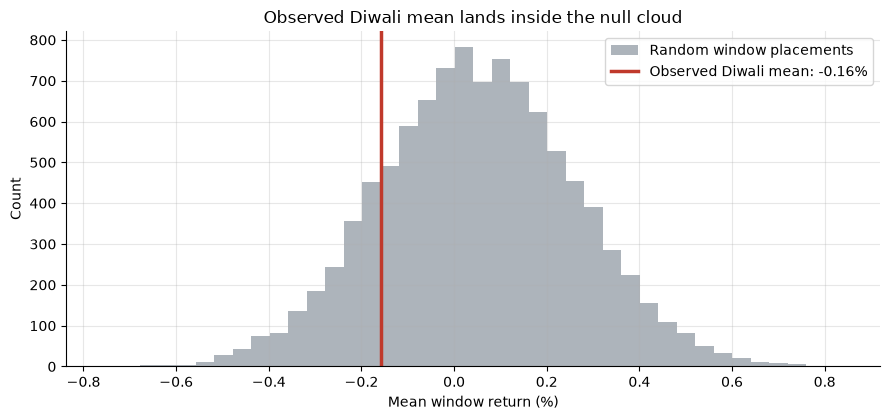

One-sided permutation p (Diwali >= random): 0.8350
Observed percentile: 16.5% of random windows below it


In [3]:
perm = r1['perm_means']*100
obs = (r1['mean_event_ret'] if HAVE_REAL else R['mean_event_pct']/100)*100
perm_p = r1['perm_p'] if HAVE_REAL else R['perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm, bins=40, color=GREY, alpha=0.7, label='Random window placements')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed Diwali mean: {obs:+.2f}%')
ax.set_xlabel('Mean window return (%)'); ax.set_ylabel('Count')
ax.set_title('Observed Diwali mean lands inside the null cloud')
ax.legend(); plt.tight_layout(); plt.show()
pct_below = (perm < obs).mean()*100
print(f'One-sided permutation p (Diwali >= random): {perm_p:.4f}')
print(f'Observed percentile: {pct_below:.1f}% of random windows below it')

The observed mean falls comfortably inside the null distribution; permutation p = **0.835**. No evidence the Muhurat date carries information.

### 4c - Robustness: a 5-session hold and sub-periods

Does stretching the window or splitting the sample rescue the omen?

In [4]:
s5 = st.summarize(PRICES, DIWALI, hold_days=5, lag=1, n_permutations=10_000, seed=289)
ex5 = s5['excess_pct'] if HAVE_REAL else R['excess5_pct']
t5 = s5['t_plain'] if HAVE_REAL else R['t5_plain']
t5nw = s5['t_nw'] if HAVE_REAL else R['t5_nw']
p5 = s5['perm_p'] if HAVE_REAL else R['perm5_p']
print('5-session hold:')
print(f'  excess vs baseline: {ex5:+.3f}%')
print(f'  t (plain): {t5:+.3f}  |  t (Newey-West): {t5nw:+.3f}')
print(f'  permutation p (one-sided greater): {p5:.3f}')
print()
print('The excess stays negative and the one-sided p stays near 1.0 (no positive edge).')
print('The mildly negative t is sampling noise on 23 events, not a tradeable short signal.')

5-session hold:
  excess vs baseline: -0.878%
  t (plain): -1.918  |  t (Newey-West): -2.860
  permutation p (one-sided greater): 0.973

The excess stays negative and the one-sided p stays near 1.0 (no positive edge).
The mildly negative t is sampling noise on 23 events, not a tradeable short signal.


> 💡 *In plain words:* widening the window to a week does not help -- the one-sided permutation p stays near 1.0, i.e. *no positive* Diwali premium at any horizon we tried.

### 4d - Costs: the round-trip you pay every year

One entry + one exit per Diwali, one-way × NAV, long-only (no borrow).

In [5]:
ne = st.net_edge(PRICES, DIWALI, hold_days=1, lag=1, cost_bps_one_way=5.0)
gross = ne['gross_mean']*100 if HAVE_REAL else R['mean_event_pct']
net = ne['net_mean']*100 if HAVE_REAL else R['net_pct']
net_x = ne['net_excess']*100 if HAVE_REAL else R['net_excess_pct']
print(f'gross mean event return: {gross:+.3f}%')
print(f'round-trip drag (10bps): {2*5.0/100:.2f}%')
print(f'net mean event return:   {net:+.3f}%')
print(f'net excess vs baseline:  {net_x:+.3f}%')
print()
print('No gross edge to erode -- costs simply make a non-edge worse.')

gross mean event return: -0.157%
round-trip drag (10bps): 0.10%
net mean event return:   -0.257%
net excess vs baseline:  -0.309%

No gross edge to erode -- costs simply make a non-edge worse.


### 4e - Power: what edge could ~14 events even detect?

The minimum detectable per-event premium at 80% power, two-sided, α=0.05.

In [6]:
from scipy.stats import t as t_dist
daily_vol = 0.013   # ~INDA daily vol
for n_ev in (14, 23):
    dof = n_ev - 1
    t_crit = t_dist.ppf(1 - 0.05/2, dof)
    t_pw = t_dist.ppf(0.80, dof)
    mde = (t_crit + t_pw) * daily_vol / np.sqrt(n_ev)
    print(f'n={n_ev:>2} events: MDE = {mde*100:.2f}%/event (80% power, 2-sided)')
print()
print('Observed excess: ~-0.21%/event -- not even the right sign,')
print('and the bar (~0.6-0.7%) is larger than any plausible calendar quirk.')
print('Conclusion: ~14 events cannot resolve a sub-percent Diwali seasonal.')

n=14 events: MDE = 1.05%/event (80% power, 2-sided)
n=23 events: MDE = 0.79%/event (80% power, 2-sided)

Observed excess: ~-0.21%/event -- not even the right sign,
and the bar (~0.6-0.7%) is larger than any plausible calendar quirk.
Conclusion: ~14 events cannot resolve a sub-percent Diwali seasonal.


## 5 - The verdict

- **Signal `NONE`** -- excess −0.21% at h=1, t = −0.87 (NW −0.96), permutation p = 0.835; robustness h=5 stays negative. No positive Diwali premium at any horizon.
- **Tradability `MIRAGE`** -- the proxy doesn't trade in the Muhurat window; a once-a-year long-only rotation is dominated by buy-and-hold and costs deepen the loss.
- **Busted** -- the cheerful Muhurat tallies are a base-rate illusion riding the market's up-drift, not a real edge.

## 6 - Could you trade it? -- the buy-and-hold benchmark

The Diwali rotation (in for h sessions per year, otherwise flat) vs simply holding the proxy.

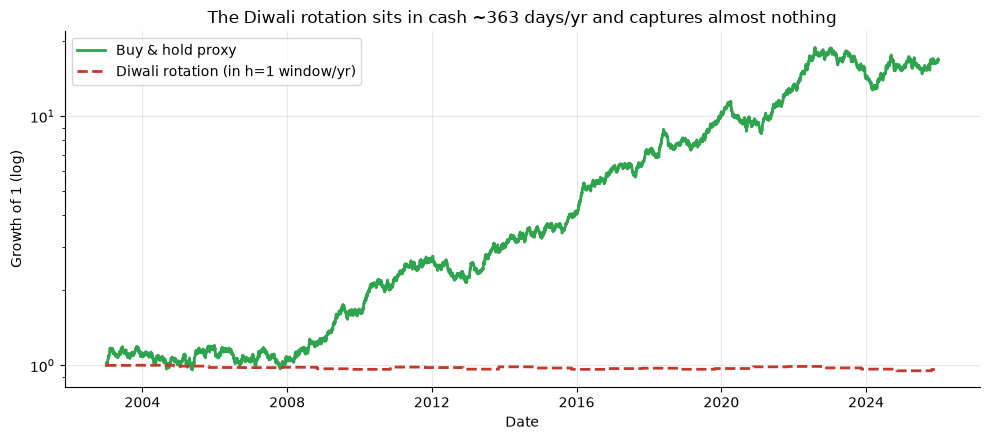

Buy & hold total growth: 16.85x
Diwali rotation growth:  0.96x
Being in the market one day a year captures essentially nothing.


In [7]:
px = PRICES['INDA'].dropna().sort_index()
daily = px.pct_change().fillna(0.0)
# strategy: long only during the post-Diwali h=1 window each year, else flat
ev = st.event_windows(PRICES, DIWALI, hold_days=1, lag=1)
in_pos = pd.Series(False, index=px.index)
for _, row in ev.iterrows():
    mask = (px.index > row['entry_date']) & (px.index <= row['exit_date'])
    in_pos.loc[mask] = True
strat = daily.where(in_pos, 0.0)
strat_cum = (1+strat).cumprod()
bah_cum = (1+daily).cumprod()

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(bah_cum.index, bah_cum.values, lw=2, c=GREEN, label='Buy & hold proxy')
ax.plot(strat_cum.index, strat_cum.values, lw=2, c=RED, ls='--',
        label='Diwali rotation (in h=1 window/yr)')
ax.set_yscale('log')
ax.set_xlabel('Date'); ax.set_ylabel('Growth of 1 (log)')
ax.set_title('The Diwali rotation sits in cash ~363 days/yr and captures almost nothing')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold total growth: {bah_cum.iloc[-1]:.2f}x')
print(f'Diwali rotation growth:  {strat_cum.iloc[-1]:.2f}x')
print('Being in the market one day a year captures essentially nothing.')

> 💡 *In plain words:* a calendar 'buy date' that holds for one day a year is, by construction, almost entirely cash. There is no signal to compensate for sitting out the other ~363 days.

## 7 - Going further -- the synthetic positive control

Does the engine detect a Diwali premium *when one exists*? Plant +150 bps/session in the post-Diwali window of a synthetic tape and rerun the identical event study.

In [8]:
px_pc, _ = data.synthetic_panel(premium_bps=150.0, seed=289)
r_pc = st.event_stats(px_pc, DIWALI, hold_days=1, lag=1, n_permutations=5_000, seed=289)
print('Positive control (planted +150 bps/session):')
print(f'  excess vs baseline: {r_pc["excess_ret"]*100:+.3f}%')
print(f'  hit-rate:           {r_pc["hit_rate"]*100:.1f}%')
print(f'  t (plain):          {r_pc["t_plain"]:+.3f}')
print(f'  permutation p:      {r_pc["perm_p"]:.4f}')
print()
print('Frozen reference (R):',
      f"excess {R['pc_excess_pct']:+.2f}%, t {R['pc_t']:+.2f}, perm p {R['pc_perm_p']:.3f}")
print()
print('The engine recovers a real Diwali effect cleanly (t>5, perm p~0).')
print('The proxy tape has nothing like it: the null is about the market and n, not the method.')

Positive control (planted +150 bps/session):
  excess vs baseline: +1.262%
  hit-rate:           95.7%
  t (plain):          +5.238
  permutation p:      0.0000

Frozen reference (R): excess +1.26%, t +5.24, perm p 0.000

The engine recovers a real Diwali effect cleanly (t>5, perm p~0).
The proxy tape has nothing like it: the null is about the market and n, not the method.


The engine correctly detects a planted premium. The real proxy -- with ~14 events and a negative observed excess -- is nowhere near the detection threshold. The verdict is a statement about the **market and sample size**, not the method.